In [2]:
import numpy as np
import matplotlib.pyplot as plt
import athena_mc as athenamc
from scipy.optimize import curve_fit
from scipy.integrate import quad
import final_proj as fitting

In [3]:
folder = "xrb_d01_s3_1e9"

In [4]:
spec = athenamc.read_spectrum(f"../{folder}/xrb.out1.spec")

imu = 0
iphi = 0

xfaces = spec['xfaces']
x = 0.5*(xfaces[1:]+xfaces[:-1])
y = spec["intensity"][0,iphi,imu,:]
yerr = spec["errors"][0,iphi,imu,:]

print(x.shape, y.shape, yerr.shape)

np.savetxt(
    "output.txt",
    np.column_stack([x, y, yerr]),
    header="x y yerr"
)

(48,) (48,) (48,)


In [5]:
A_pow_fit, A_pow_err, alpha_fit, alpha_err = fitting.pow(x, y, yerr)
A_bb_fit, A_bb_err, T_fit, T_err = fitting.bb(x, y, yerr)
A, Aerr, Tin, Tinerr, Tout, Touterr = fitting.diskbb(x, y, yerr)
A_pow_fit_comp, A_pow_err_comp, alpha_fit_comp, alpha_err_comp, A_bb_fit_comp, A_bb_err_comp, Tin_fit_comp, Tin_err_comp, Tout_fit_comp, Tout_err_comp = fitting.composite(x, y, yerr)
#A_pow_fit_comp, A_pow_err_comp, alpha_fit_comp, alpha_err_comp, A_bb_fit_comp, A_bb_err_comp, T_fit_comp, T_err_comp = fitting.composite_bb(x,y,yerr)

/PellaShared/jez2sk/xray_binaries/final_gr_scattering_runs/astr4460_final_prject/final_proj.py:8: RuntimeWarning: overflow encountered in power
  return A * E**(-alpha)
/PellaShared/jez2sk/xray_binaries/final_gr_scattering_runs/astr4460_final_prject/final_proj.py:8: RuntimeWarning: overflow encountered in multiply
  return A * E**(-alpha)
/PellaShared/jez2sk/xray_binaries/final_gr_scattering_runs/astr4460_final_prject/final_proj.py:25: RuntimeWarning: overflow encountered in exp
  return A * (E**3) / (np.exp(E / T) - 1)
/PellaShared/jez2sk/xray_binaries/final_gr_scattering_runs/astr4460_final_prject/final_proj.py:44: RuntimeWarning: invalid value encountered in scalar power
  return (T / Tin)**(-11/3) * blackbody(E, 1, T) / Tin
/PellaShared/jez2sk/xray_binaries/final_gr_scattering_runs/astr4460_final_prject/final_proj.py:50: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimate

power law fit parameters:
A = 4.828e+24 ± 1.702e+23
alpha = 1.160 ± 0.005

bb fit parameters:
A = 4.898e+12 ± 3.145e+11
T = 667.335 ± 9.649

diskbb fit parameters:
A     = 1.584e+14 ± 9.498e+12
Tin   = 360.188 ± 5.376
Tout  = 3.770 ± 4651616.591

Composite fit parameters:
A_pow  = -1.972e+27 ± inf
alpha  = 156817.887 ± inf
A_bb   = 1.584e+14 ± inf
Tin    = 360.194 ± inf
Tout   = 0.366 ± inf



/PellaShared/jez2sk/xray_binaries/final_gr_scattering_runs/astr4460_final_prject/final_proj.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(comp, x, y, sigma=yerr, absolute_sigma=True, p0=[1e22, 2, 1e20, 500, 50], maxfev=20000)


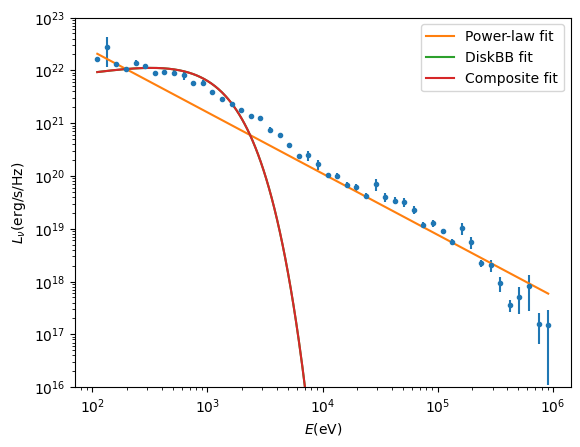

In [7]:
plt.errorbar(x, y, yerr=yerr, fmt='o', markersize=3)

xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
plt.plot(xfit, fitting.power_law(xfit, A_pow_fit, alpha_fit), label='Power-law fit')
#plt.plot(xfit, fitting.blackbody(xfit, A_bb_fit, T_fit), label='Blackbody fit')
plt.plot(xfit, fitting.diskbb_model(xfit, A, Tin, Tout), label='DiskBB fit')
plt.plot(xfit, fitting.comp(xfit, A_pow_fit_comp, alpha_fit_comp, A_bb_fit_comp, Tin_fit_comp, Tout_fit_comp), label='Composite fit')
#plt.plot(xfit, comp_bb(xfit, A_pow_fit_comp, alpha_fit_comp, A_bb_fit_comp, T_fit_comp), label='composite fit')


plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$E {\rm (eV)}$")
plt.ylabel(r"$L_\nu {\rm (erg/s/Hz)}$")
plt.ylim(1e16, 1e23)
plt.legend()

plt.show()